In [ ]:
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [ ]:
# !unzip "archive(6).zip"

In [ ]:


features = pd.read_csv("/content/elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("/content/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")
edges = pd.read_csv("/content/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")

print(features.shape)
print(classes.shape)
print(edges.shape)

(203769, 167)
(203769, 2)
(234355, 2)


In [ ]:
features.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [ ]:
classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [ ]:
edges.head()


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [ ]:
features.rename(columns={0:"txId"}, inplace=True)

data = features.merge(classes, on="txId")

data = data[data["class"] != "unknown"]
data["class"] = data["class"].astype(int) - 1

data.head()

,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,1
9,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,1
10,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1
11,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1
16,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,1


In [ ]:
x = torch.tensor(data.iloc[:,1:-1].values, dtype=torch.float)
y = torch.tensor(data["class"].values, dtype=torch.long)
tx_ids = data["txId"].values
tx_id_map = {tx_id: i for i, tx_id in enumerate(tx_ids)}
# edge_index = torch.tensor(edges.values.T, dtype=torch.long)
edge_list = []

for _, row in edges.iterrows():

    src = row["txId1"]
    dst = row["txId2"]

    if src in tx_id_map and dst in tx_id_map:
        edge_list.append([tx_id_map[src], tx_id_map[dst]])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
graph_data = Data(x=x, edge_index=edge_index, y=y)

print(graph_data)

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])


In [ ]:
# import networkx as nx

# G = nx.from_pandas_edgelist(
#     edges,
#     source="txId1",
#     target="txId2"
# )

# print("Nodes:", G.number_of_nodes())
# print("Edges:", G.number_of_edges())

In [ ]:
# !pip install torch torch-geometric
# from torch_geometric.utils import from_networkx

# data = from_networkx(G)

In [ ]:
# import torch
# from torch_geometric.nn import GCNConv
# import torch.nn.functional as F

class GNN(torch.nn.Module):

    def __init__(self, num_features, num_classes):
        super().__init__()

        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, 32)
        self.conv3 = GCNConv(32, num_classes)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        return x

from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(graph_data.y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=graph_data.y.numpy()
)


In [ ]:
num_features = graph_data.x.shape[1]

model = GNN(num_features, 2)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# weights = torch.tensor([1,4], dtype=torch.float)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(graph_data.y.numpy()),
    y=graph_data.y.numpy()
)

weights = torch.tensor(class_weights, dtype=torch.float)
for epoch in range(50):

    optimizer.zero_grad()

    out = model(graph_data)
    loss = F.cross_entropy(
    out[train_idx],
    graph_data.y[train_idx],
    weight=weights
    )
    loss.backward()

    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 2.0430517196655273
Epoch: 1 Loss: 1.0019627809524536
Epoch: 2 Loss: 0.916291356086731
Epoch: 3 Loss: 0.597072422504425
Epoch: 4 Loss: 0.5319617986679077
Epoch: 5 Loss: 0.5886664390563965
Epoch: 6 Loss: 0.6020310521125793
Epoch: 7 Loss: 0.5367431640625
Epoch: 8 Loss: 0.45692041516304016
Epoch: 9 Loss: 0.4513154625892639
Epoch: 10 Loss: 0.484645277261734
Epoch: 11 Loss: 0.46576830744743347
Epoch: 12 Loss: 0.41829636693000793
Epoch: 13 Loss: 0.3955889642238617
Epoch: 14 Loss: 0.4043698012828827
Epoch: 15 Loss: 0.41419097781181335
Epoch: 16 Loss: 0.4048352837562561
Epoch: 17 Loss: 0.3811846673488617
Epoch: 18 Loss: 0.36189553141593933
Epoch: 19 Loss: 0.35943612456321716
Epoch: 20 Loss: 0.36580607295036316
Epoch: 21 Loss: 0.36392709612846375
Epoch: 22 Loss: 0.35004058480262756
Epoch: 23 Loss: 0.33582422137260437
Epoch: 24 Loss: 0.3326234519481659
Epoch: 25 Loss: 0.3367968797683716
Epoch: 26 Loss: 0.3357483744621277
Epoch: 27 Loss: 0.32640770077705383
Epoch: 28 Loss: 0.3169324

In [ ]:
pred = out.argmax(dim=1)

print(classification_report(
    graph_data.y[test_idx].cpu(),
    pred[test_idx].cpu()
))

              precision    recall  f1-score   support

           0       0.47      0.88      0.61       909
           1       0.99      0.89      0.94      8404

    accuracy                           0.89      9313
   macro avg       0.73      0.89      0.77      9313
weighted avg       0.94      0.89      0.90      9313



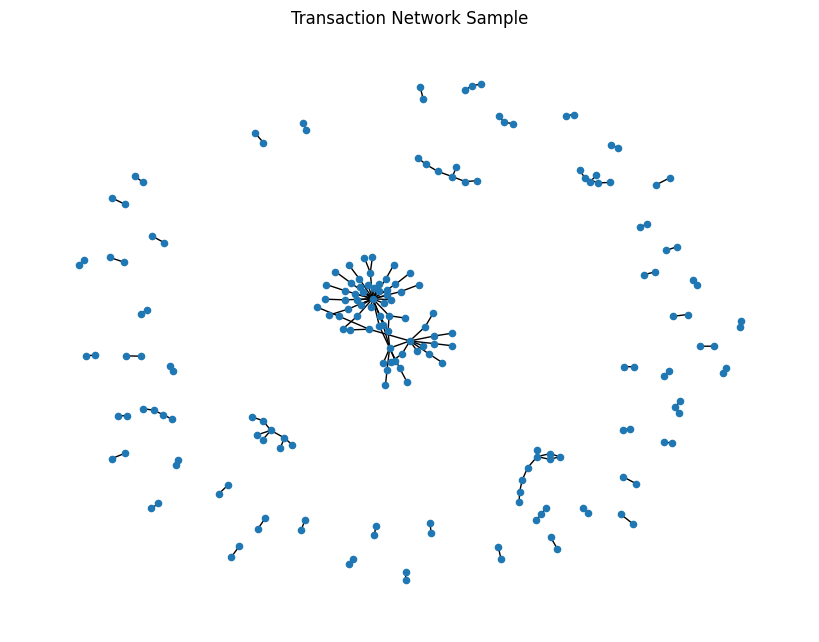

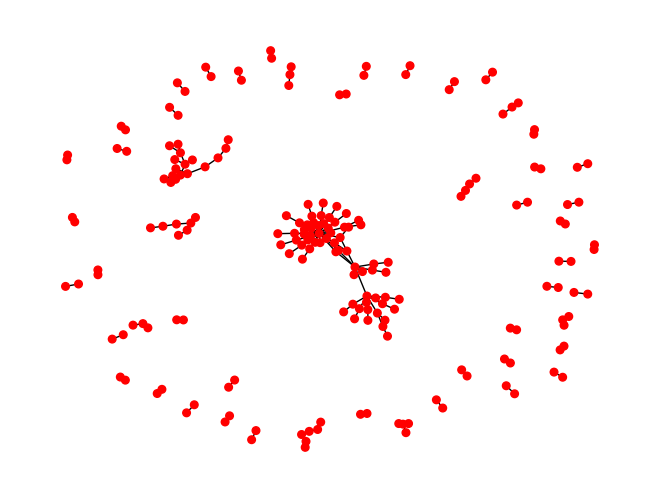

In [ ]:
import networkx as nx
G = nx.Graph()

edges_list = edge_index.T.tolist()

G.add_edges_from(edges_list)
sub_nodes = list(G.nodes())[:200]

subgraph = G.subgraph(sub_nodes)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

nx.draw(subgraph, node_size=20)

plt.title("Transaction Network Sample")

plt.show()
colors = ["red" if pred[i]==1 else "blue" for i in sub_nodes]

nx.draw(subgraph, node_color=colors, node_size=30)

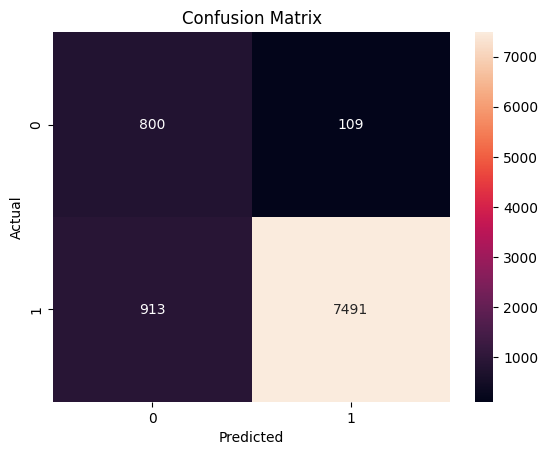

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    graph_data.y[test_idx].cpu(),
    pred[test_idx].cpu()
)
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()